# Experiment: TrustMe GazeMAE Embeddings Inspection

Inspect schema, quality metadata, and embedding geometry for `data/gazemae_outputs/trustme_gazemae_embeddings.parquet`.
The notebook auto-samples rows for heavy operations if needed.


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
np.random.seed(SEED)

ROOT = Path("..").resolve()
print(f"ROOT: {ROOT}")

EMBEDDINGS_PATH = Path(ROOT / "data/gazemae_outputs/trustme_gazemae_embeddings.parquet")
SUMMARY_PATH = Path(ROOT / "data/gazemae_outputs/trustme_gazemae_run_summary.json")

# If the file is large, sample for expensive operations.
MAX_ROWS_FOR_HEAVY = 50_000
EMBEDDINGS_PATH, SUMMARY_PATH


ROOT: /home/ppg/eyetracking/gazemae


(PosixPath('/home/ppg/eyetracking/gazemae/data/gazemae_outputs/trustme_gazemae_embeddings.parquet'),
 PosixPath('/home/ppg/eyetracking/gazemae/data/gazemae_outputs/trustme_gazemae_run_summary.json'))

In [2]:
assert EMBEDDINGS_PATH.exists(), f"Missing embeddings file: {EMBEDDINGS_PATH}"
assert SUMMARY_PATH.exists(), f"Missing summary file: {SUMMARY_PATH}"

summary = json.loads(SUMMARY_PATH.read_text())
summary


{'config': {'batch_size': 256,
  'device': 'auto',
  'include_z_concat': False,
  'input_root': 'data/TrustMe',
  'max_files_per_subject': 0,
  'max_invalid_frames': 60,
  'max_windows_per_file': 0,
  'min_valid_fraction': 0.3,
  'min_valid_frames': 32,
  'model_pos': 'models/pos-i3738',
  'model_vel': 'models/vel-i8528',
  'num_workers': 0,
  'out_dir': 'data/gazemae_outputs',
  'subjects': [],
  'target_hz': 500,
  'verbose': False,
  'window_seconds': 3.0},
 'generated_at_utc': '2026-03-11T13:04:53.751670+00:00',
 'models': {'model_pos': 'models/pos-i3738', 'model_vel': 'models/vel-i8528'},
 'outputs': {'embeddings_parquet': 'data/gazemae_outputs/trustme_gazemae_embeddings.parquet',
  'rows_written': 132350,
  'summary_json': 'data/gazemae_outputs/trustme_gazemae_run_summary.json'},
 'pipeline': 'trustme_gazemae_embeddings',
 'stats': {'drop_reason_counts': {'low_valid_fraction': 411111,
   'too_few_valid_frames': 8},
  'parquet_files_processed': 65,
  'subjects_processed': 2,
  'to

In [3]:
df = pd.read_parquet(EMBEDDINGS_PATH)
n_rows = len(df)
size_mb = EMBEDDINGS_PATH.stat().st_size / (1024 * 1024)

print(f"Rows: {n_rows:,}")
print(f"Columns: {len(df.columns)}")
print(f"File size: {size_mb:.2f} MB")

z_pos_cols = [c for c in df.columns if c.startswith("z_pos_")]
z_vel_cols = [c for c in df.columns if c.startswith("z_vel_")]
z_concat_cols = [c for c in df.columns if c.startswith("z_concat_")]

print(f"z_pos dims: {len(z_pos_cols)}")
print(f"z_vel dims: {len(z_vel_cols)}")
print(f"z_concat dims: {len(z_concat_cols)}")

display(df.head(3))


Rows: 132,350
Columns: 281
File size: 148.69 MB
z_pos dims: 128
z_vel dims: 128
z_concat dims: 0


,window_uid,subject,source_file,window_id,window_id_str,orig_len,valid_count,valid_fraction,start_t,end_t,...,z_vel_118,z_vel_119,z_vel_120,z_vel_121,z_vel_122,z_vel_123,z_vel_124,z_vel_125,z_vel_126,z_vel_127
0,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1286,1286,114,95,0.833333,299.785,2192.495,...,-1.024652,-0.912763,-0.891846,-1.867878,-1.398821,-3.159577,-0.316538,-1.393319,-0.682972,-1.277284
1,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1287,1287,179,159,0.888268,1460.185,4445.796,...,-1.209832,3.001952,-1.112411,-1.740260,1.659105,-2.257048,-0.316538,-0.607105,-0.682972,-1.277284
2,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1288,1288,180,159,0.883333,3711.370,6690.598,...,-2.727127,-0.894701,6.827636,-1.867878,5.531495,-2.458467,-0.316538,-1.393319,-0.682972,-1.277284


In [4]:
meta_cols = [
    c
    for c in [
        "window_uid", "subject", "source_file", "window_id", "window_id_str",
        "orig_len", "valid_count", "valid_fraction", "start_t", "end_t",
        "target_hz", "window_seconds", "target_len", "sleep_feedback", "prompt_id", "prompt_time"
    ]
    if c in df.columns
]

print("Metadata columns present:")
print(meta_cols)

if "subject" in df.columns:
    display(df["subject"].value_counts().rename("rows_per_subject").to_frame())

if "valid_fraction" in df.columns:
    display(df["valid_fraction"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("valid_fraction"))

if "orig_len" in df.columns:
    display(df["orig_len"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("orig_len"))


Metadata columns present:
['window_uid', 'subject', 'source_file', 'window_id', 'window_id_str', 'orig_len', 'valid_count', 'valid_fraction', 'start_t', 'end_t', 'target_hz', 'window_seconds', 'target_len', 'sleep_feedback', 'prompt_id', 'prompt_time']


,rows_per_subject
subject,
s_005_ak,73622
s_004_pk,58728


,valid_fraction
count,132350.000000
mean,0.872879
std,0.170831
min,0.300000
10%,0.592090
25%,0.834254
50%,0.944444
75%,1.000000
90%,1.000000
max,1.000000


,orig_len
count,132350.000000
mean,179.170087
std,4.411779
min,42.000000
10%,177.000000
25%,180.000000
50%,180.000000
75%,180.000000
90%,181.000000
max,185.000000


In [5]:
# NaN checks in embeddings.
embedding_cols = z_pos_cols + z_vel_cols + z_concat_cols
nan_any = bool(df[embedding_cols].isna().any().any()) if embedding_cols else False
print("Any NaN in embedding columns:", nan_any)

if embedding_cols:
    emb_matrix = df[embedding_cols].to_numpy(dtype=np.float32)
    print("Embedding matrix shape:", emb_matrix.shape)
    print("Embedding global mean/std:", round(float(emb_matrix.mean()), 2), round(float(emb_matrix.std()), 2))

    embed_norms = np.linalg.norm(emb_matrix, axis=1)
    print("Embedding norms - mean/std:", round(float(embed_norms.mean()), 2), round(float(embed_norms.std()), 2))
    print("Embedding norms - min/max:", round(float(embed_norms.min()), 2), round(float(embed_norms.max()), 2))


Any NaN in embedding columns: False
Embedding matrix shape: (132350, 256)
Embedding global mean/std: 16.41 2577.08
Embedding norms - mean/std: 1581.83 41203.82
Embedding norms - min/max: 7.81 4726615.5


In [6]:
# Use subset for expensive steps.
if n_rows > MAX_ROWS_FOR_HEAVY:
    df_heavy = df.sample(n=MAX_ROWS_FOR_HEAVY, random_state=SEED).reset_index(drop=True)
    print(f"Using subset for heavy analysis: {len(df_heavy):,} rows")
else:
    df_heavy = df.copy()
    print(f"Using full dataset for heavy analysis: {len(df_heavy):,} rows")

heavy_cols = z_pos_cols + z_vel_cols
X = df_heavy[heavy_cols].to_numpy(dtype=np.float32)
X.shape


Using subset for heavy analysis: 50,000 rows


(50000, 256)

Using random subset of 5,000 for PCA: 50,000 rows


Explained variance ratio (PC1, PC2): [0.9862231  0.01060499]
Inliers kept for PCA plot: 4,457 / 5,000 (89.1%)
PC2~PC1 slope=2.8326, intercept=-3947.4619


,PC1,PC2,PC2_resid
count,4457.000000,4457.000000,4457.000000
mean,1468.026611,210.816055,-0.000118
std,0.187548,0.540680,0.100584
min,1467.400269,209.087570,-0.877594
25%,1467.926758,210.530762,-0.038635
50%,1468.053223,210.884247,0.016602
75%,1468.159058,211.191925,0.062958
max,1468.432739,212.012070,0.321655



PCA plot (outliers removed) colored by 'subject':


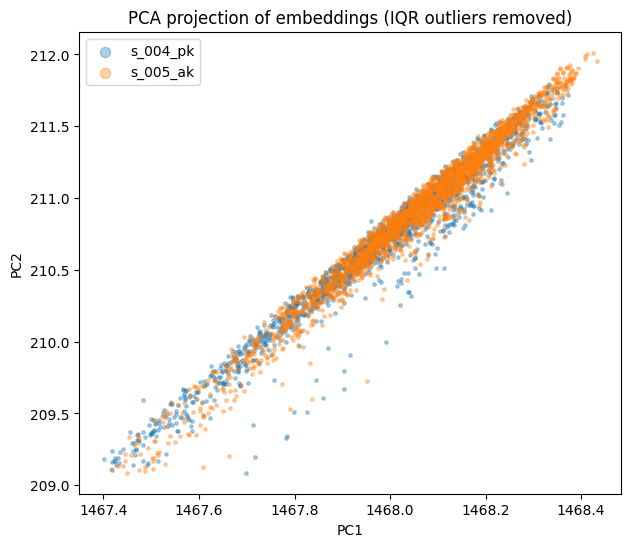


PCA plot (outliers removed) colored by 'sleep_feedback':


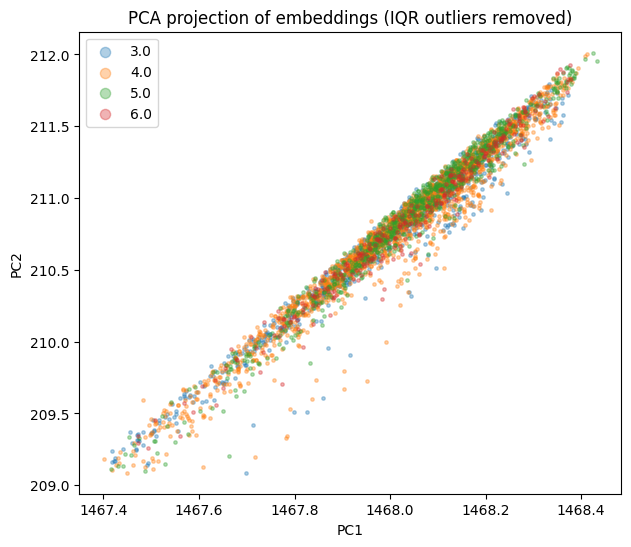

In [7]:
RANDOM_SUBSET_SIZE = 5_000
if len(X) > RANDOM_SUBSET_SIZE:
    subset_idxs = np.random.choice(len(X), size=RANDOM_SUBSET_SIZE, replace=False)
    X_temp = X[subset_idxs]
    df_temp = df_heavy.iloc[subset_idxs].reset_index(drop=True)
    print(f"Using random subset of {RANDOM_SUBSET_SIZE:,} for PCA: {len(X):,} rows")
else:
    X_temp = X
    df_temp = df_heavy.reset_index(drop=True)
    print(f"Using full heavy subset for PCA: {len(X_temp):,} rows")

# Quick 2D projection with PCA via NumPy SVD.
# Outliers are removed in PC space with an IQR rule before plotting/metadata probing.
X_centered = X_temp - X_temp.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords_2d = U[:, :2] * S[:2]
explained_ratio = (S ** 2) / np.sum(S ** 2)
print("Explained variance ratio (PC1, PC2):", explained_ratio[:2])

pc1 = coords_2d[:, 0]
pc2 = coords_2d[:, 1]

def iqr_bounds(x: np.ndarray, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = np.quantile(x, [0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

l1, u1 = iqr_bounds(pc1, k=1.5)
l2, u2 = iqr_bounds(pc2, k=1.5)
inlier_mask = (pc1 >= l1) & (pc1 <= u1) & (pc2 >= l2) & (pc2 <= u2)

n_total = len(coords_2d)
n_inliers = int(inlier_mask.sum())
print(f"Inliers kept for PCA plot: {n_inliers:,} / {n_total:,} ({n_inliers / n_total:.1%})")

coords_plot = coords_2d[inlier_mask]
pc_df = df_temp.loc[inlier_mask].reset_index(drop=True).copy()
pc_df["PC1"] = coords_plot[:, 0]
pc_df["PC2"] = coords_plot[:, 1]

# Residual against main diagonal trend (useful for weak effects hidden by near-1D geometry).
A = np.vstack([pc_df["PC1"].to_numpy(), np.ones(len(pc_df))]).T
slope, intercept = np.linalg.lstsq(A, pc_df["PC2"].to_numpy(), rcond=None)[0]
pc_df["PC2_resid"] = pc_df["PC2"] - (slope * pc_df["PC1"] + intercept)
print(f"PC2~PC1 slope={slope:.4f}, intercept={intercept:.4f}")

display(pc_df[["PC1", "PC2", "PC2_resid"]].describe())

observed_cols = ["subject", "sleep_feedback"]
for observed_col in observed_cols:
    print(f"\nPCA plot (outliers removed) colored by '{observed_col}':")
    fig, ax = plt.subplots(figsize=(7, 6))
    if observed_col in pc_df.columns:
        for label, g in pc_df.groupby(observed_col):
            ax.scatter(g["PC1"], g["PC2"], s=6, alpha=0.35, label=label)
        ax.legend(markerscale=3)
    else:
        ax.scatter(pc_df["PC1"], pc_df["PC2"], s=6, alpha=0.35)
    ax.set_title("PCA projection of embeddings (IQR outliers removed)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.show()



Columns selected for metadata probing: ['subject', 'sleep_feedback', 'prompt_id', 'prompt_time', '1', '2', '3', '4', '5', '6', '7', '8', '9']

=== subject ===
non-null=4,457 (100.0%), unique=2
Top categories after grouping:


,count
subject,
s_005_ak,2634
s_004_pk,1823


eta^2 PC1=0.0259 | PC2=0.0291 | PC2_resid=0.0045 | silhouette=0.0311


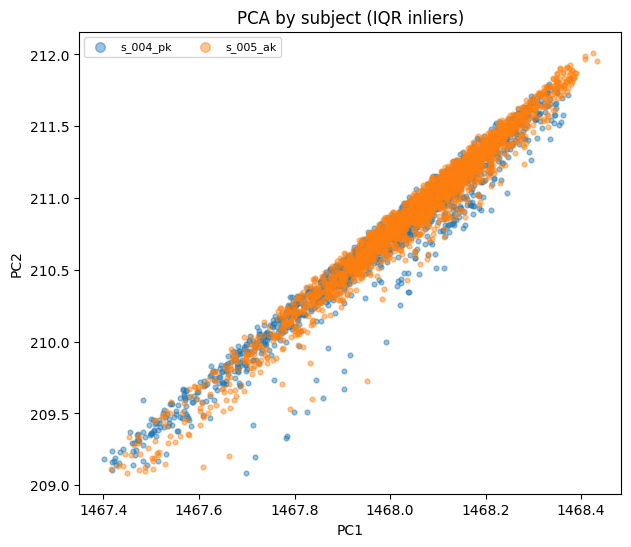


=== sleep_feedback ===
non-null=3,987 (89.45%), unique=4


Top categories after grouping:


,count
sleep_feedback,
4,1906
3,987
5,805
6,289


eta^2 PC1=0.0051 | PC2=0.0067 | PC2_resid=0.0066 | silhouette=-0.0357


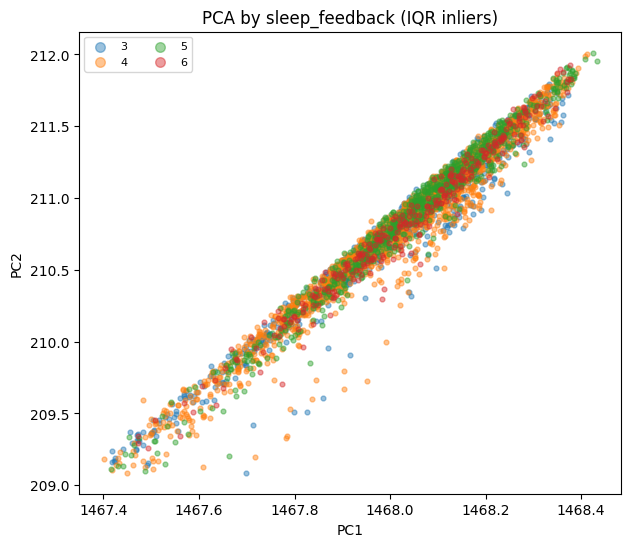


=== prompt_id ===
non-null=549 (12.32%), unique=64
Top categories after grouping:


,count
prompt_id,
Other,318
36,24
22,24
33,24
30,21
29,20
52,19
24,18
43,17


eta^2 PC1=0.0702 | PC2=0.0767 | PC2_resid=0.1586 | silhouette=-0.3405


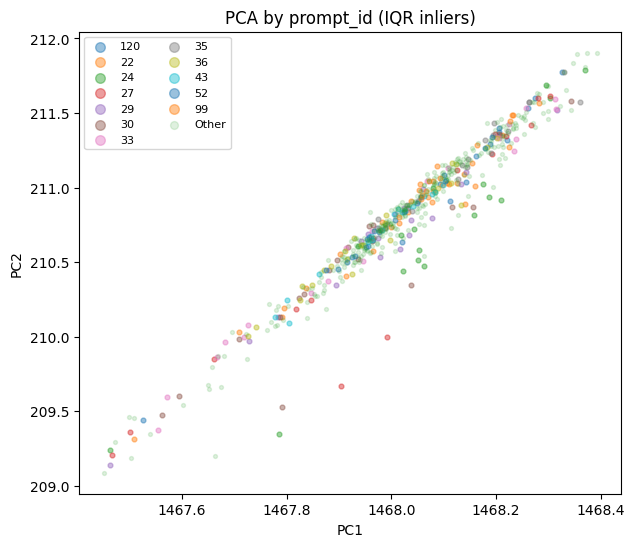


=== prompt_time ===
non-null=549 (12.32%), unique=74
rank-corr PC1=-0.0154 | PC2=-0.0123 | PC2_resid=0.0194


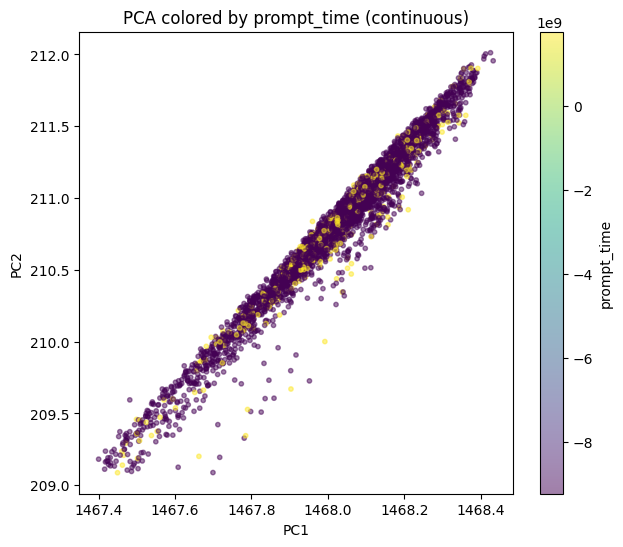


=== 1 ===
non-null=412 (9.24%), unique=4
Top categories after grouping:


,count
1,
1,206
2,102
3,56
0,48


eta^2 PC1=0.0080 | PC2=0.0040 | PC2_resid=0.0273 | silhouette=-0.1320


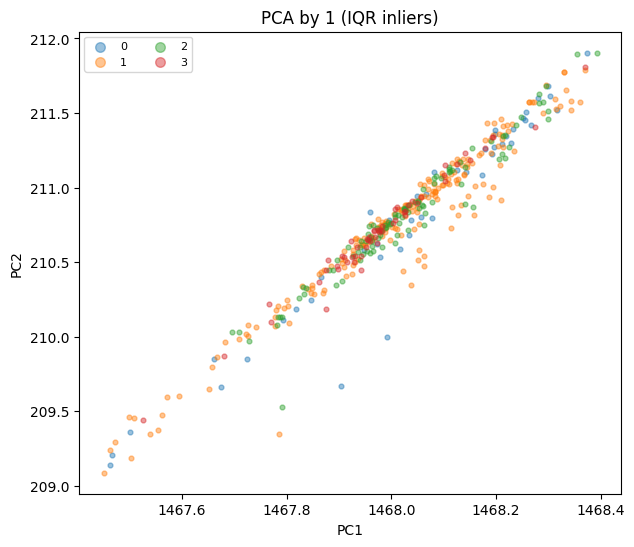


=== 2 ===
non-null=412 (9.24%), unique=6
Top categories after grouping:


,count
2,
3,159
2,84
5,63
4,55
6,37
Other,14


eta^2 PC1=0.0373 | PC2=0.0268 | PC2_resid=0.0373


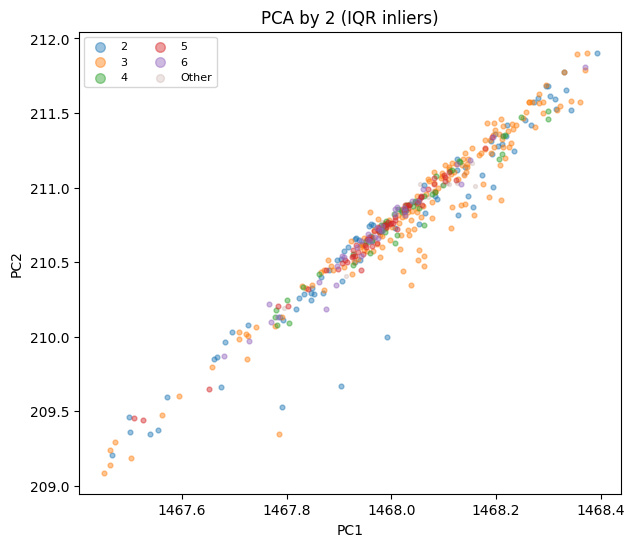


=== 3 ===
non-null=523 (11.73%), unique=7
Top categories after grouping:


,count
3,
1,160
2,136
3,94
4,78
5,29
0,25
Other,1


eta^2 PC1=0.0180 | PC2=0.0177 | PC2_resid=0.0219


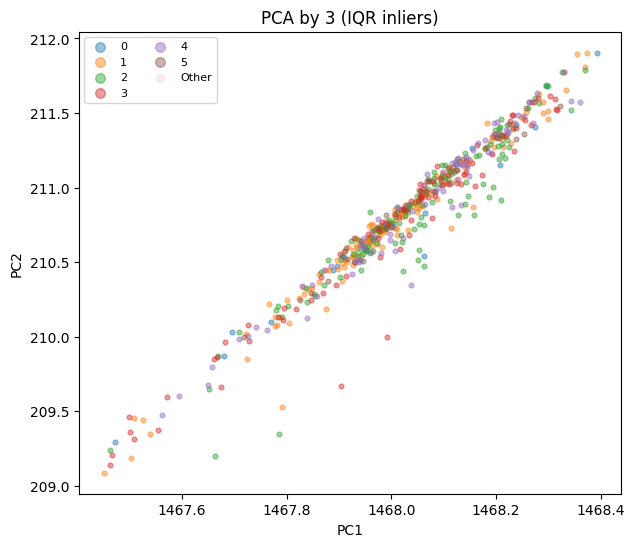


=== 4 ===
non-null=412 (9.24%), unique=7
Top categories after grouping:


,count
4,
4,112
3,99
2,96
5,48
6,41
Other,16


eta^2 PC1=0.0162 | PC2=0.0063 | PC2_resid=0.0545 | silhouette=-0.1692


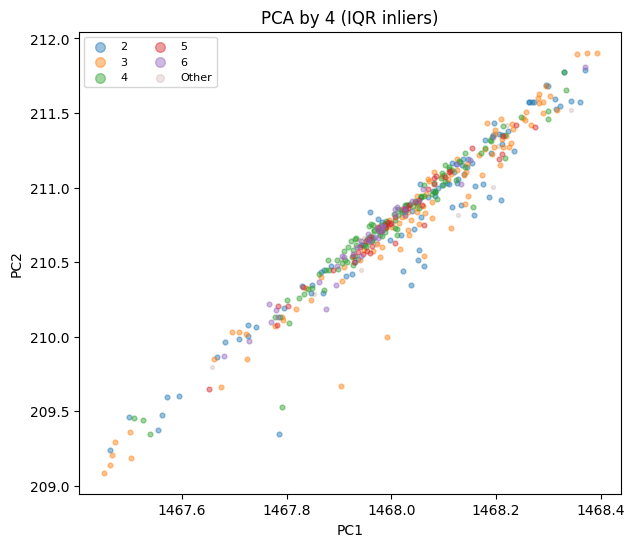


=== 5 ===
non-null=408 (9.15%), unique=6
Top categories after grouping:


,count
5,
5,107
3,88
6,83
4,58
2,46
1,26


eta^2 PC1=0.0251 | PC2=0.0256 | PC2_resid=0.0649 | silhouette=-0.1532


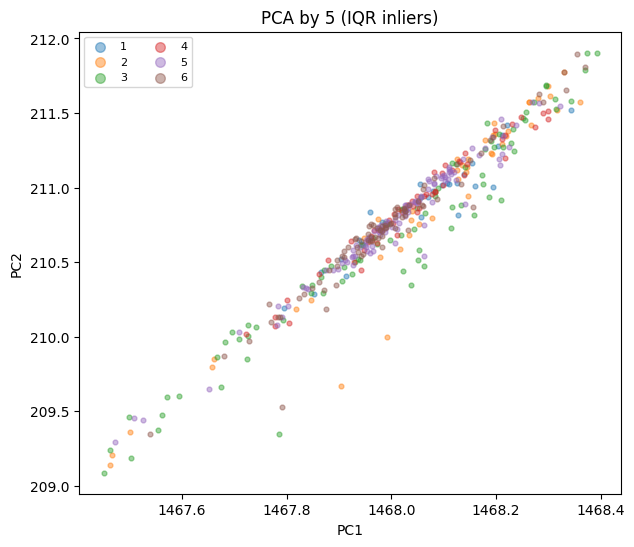


=== 6 ===
non-null=406 (9.11%), unique=4
Top categories after grouping:


,count
6,
3,273
1,114
-1,16
Other,3


eta^2 PC1=0.0369 | PC2=0.0517 | PC2_resid=0.0856


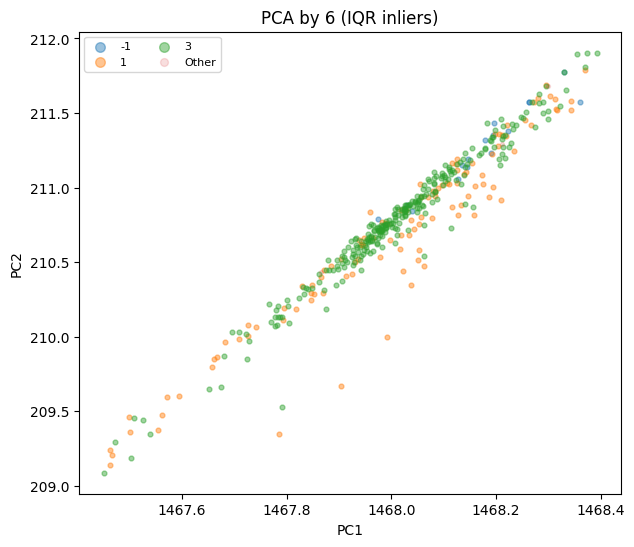


=== 7 ===
non-null=323 (7.25%), unique=3
Top categories after grouping:


,count
7,
3,163
0,103
1,57


eta^2 PC1=0.0019 | PC2=0.0099 | PC2_resid=0.0546 | silhouette=-0.0320


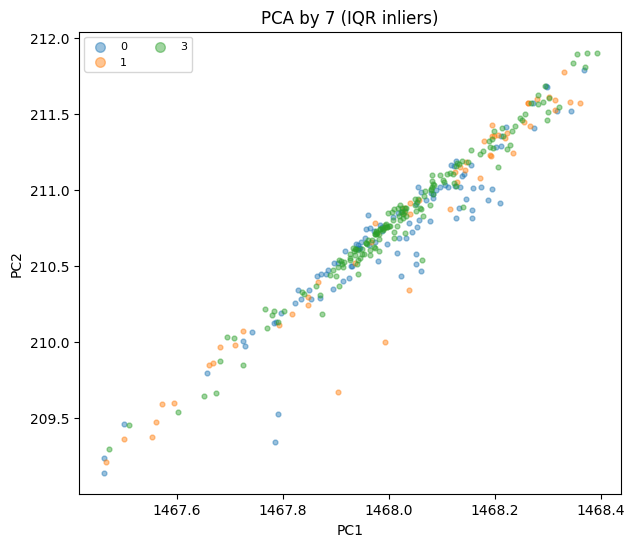


=== 8 ===
non-null=396 (8.88%), unique=6
Top categories after grouping:


,count
8,
1,145
3,85
2,74
0,69
4,21
Other,2


eta^2 PC1=0.0347 | PC2=0.0313 | PC2_resid=0.0543


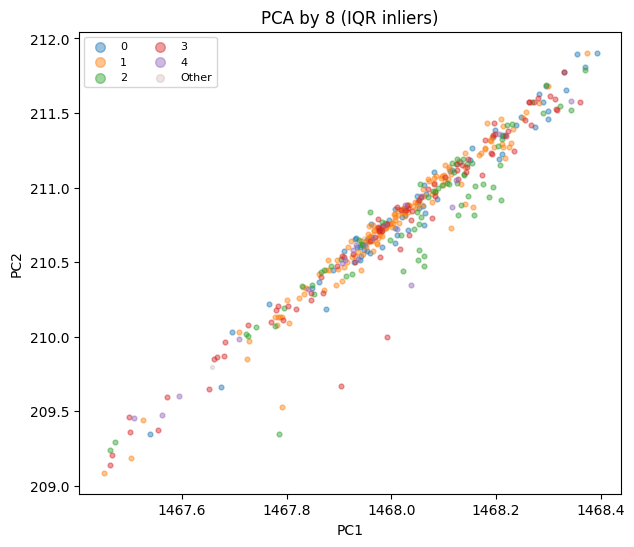


=== 9 ===
non-null=412 (9.24%), unique=6


Top categories after grouping:


,count
9,
3,130
4,81
2,78
5,67
6,38
1,18


eta^2 PC1=0.0105 | PC2=0.0159 | PC2_resid=0.0168 | silhouette=-0.1827


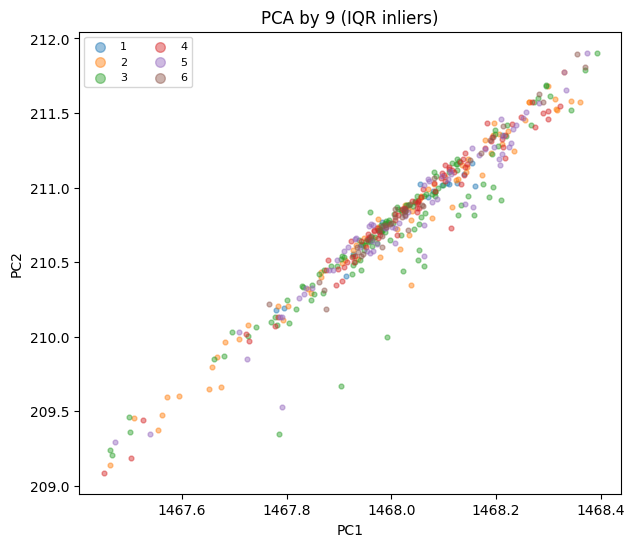


Metadata probing summary (higher signal_score = stronger axis-aligned relationship):


,column,non_null,coverage_pct,n_unique,label_type,n_groups_used,eta2_pc1,eta2_pc2,eta2_pc2_resid,silhouette_2d,signal_score,rho_pc1,rho_pc2,rho_pc2_resid
0,prompt_id,549,12.32,64,categorical,12.0,0.070183,0.076737,0.158621,-0.340488,0.158621,NaN,NaN,NaN
1,6,406,9.11,4,categorical,3.0,0.036887,0.051683,0.085601,NaN,0.085601,NaN,NaN,NaN
2,5,408,9.15,6,categorical,6.0,0.025123,0.025624,0.064894,-0.153218,0.064894,NaN,NaN,NaN
3,7,323,7.25,3,categorical,3.0,0.001941,0.009916,0.054649,-0.031965,0.054649,NaN,NaN,NaN
4,4,412,9.24,7,categorical,5.0,0.016249,0.006291,0.054529,-0.169226,0.054529,NaN,NaN,NaN
5,8,396,8.88,6,categorical,5.0,0.034702,0.031320,0.054329,NaN,0.054329,NaN,NaN,NaN
6,2,412,9.24,6,categorical,5.0,0.037253,0.026827,0.037280,NaN,0.037280,NaN,NaN,NaN
7,subject,4457,100.00,2,categorical,2.0,0.025896,0.029117,0.004533,0.031079,0.029117,NaN,NaN,NaN
8,1,412,9.24,4,categorical,4.0,0.007967,0.003996,0.027348,-0.131986,0.027348,NaN,NaN,NaN
9,3,523,11.73,7,categorical,6.0,0.017979,0.017693,0.021856,NaN,0.021856,NaN,NaN,NaN


In [8]:
from sklearn.metrics import silhouette_score

probe_cols = [
    c for c in ["subject", "sleep_feedback", "prompt_id", "prompt_time", *[str(i) for i in range(1, 10)]]
    if c in pc_df.columns
]
print("Columns selected for metadata probing:", probe_cols)

MIN_GROUP_SIZE = 15
MAX_GROUPS_FOR_PLOT = 12
MAX_SCATTER_POINTS = 4_000


def _format_value(v: object) -> str:
    if pd.isna(v):
        return "NaN"
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)) and float(v).is_integer():
        return str(int(v))
    return str(v)


def eta_squared(values: np.ndarray, labels: np.ndarray) -> float:
    if len(values) < 3:
        return float("nan")
    grand_mean = float(np.mean(values))
    ss_total = float(np.sum((values - grand_mean) ** 2))
    if ss_total <= 0:
        return float("nan")

    ss_between = 0.0
    for label in np.unique(labels):
        g = values[labels == label]
        if len(g) == 0:
            continue
        ss_between += len(g) * (float(np.mean(g)) - grand_mean) ** 2
    return float(ss_between / ss_total)


def rank_corr(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 3:
        return float("nan")
    xr = pd.Series(x).rank().to_numpy(dtype=float)
    yr = pd.Series(y).rank().to_numpy(dtype=float)
    if np.std(xr) == 0 or np.std(yr) == 0:
        return float("nan")
    return float(np.corrcoef(xr, yr)[0, 1])


def to_numeric_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_datetime64_any_dtype(s):
        return s.astype("int64") / 1e9
    return pd.to_numeric(s, errors="coerce")


rows: list[dict[str, object]] = []

for col in probe_cols:
    s = pc_df[col]
    non_null_mask = s.notna()
    n_non_null = int(non_null_mask.sum())
    n_unique = int(s[non_null_mask].nunique())

    row: dict[str, object] = {
        "column": col,
        "non_null": n_non_null,
        "coverage_pct": round(100.0 * n_non_null / len(pc_df), 2),
        "n_unique": n_unique,
    }

    print(f"\n=== {col} ===")
    print(f"non-null={n_non_null:,} ({row['coverage_pct']}%), unique={n_unique}")

    if n_non_null < 100:
        row["label_type"] = "insufficient"
        row["signal_score"] = float("nan")
        rows.append(row)
        print("Skipped: too few non-null points.")
        continue

    is_categorical = col != "prompt_time"

    if is_categorical:
        label_raw = s[non_null_mask].map(_format_value)
        counts = label_raw.value_counts(dropna=False)

        keep = counts[counts >= MIN_GROUP_SIZE].index.tolist()
        if len(keep) == 0:
            keep = counts.head(MAX_GROUPS_FOR_PLOT).index.tolist()
        if len(keep) > MAX_GROUPS_FOR_PLOT:
            keep = counts.loc[keep].sort_values(ascending=False).head(MAX_GROUPS_FOR_PLOT).index.tolist()

        label = label_raw.where(label_raw.isin(keep), other="Other")
        label_counts = label.value_counts()

        values_pc1 = pc_df.loc[non_null_mask, "PC1"].to_numpy(dtype=float)
        values_pc2 = pc_df.loc[non_null_mask, "PC2"].to_numpy(dtype=float)
        values_res = pc_df.loc[non_null_mask, "PC2_resid"].to_numpy(dtype=float)
        labels_np = label.to_numpy(dtype=str)

        eta1 = eta_squared(values_pc1, labels_np)
        eta2 = eta_squared(values_pc2, labels_np)
        eta_res = eta_squared(values_res, labels_np)

        sil = float("nan")
        if 2 <= len(label_counts) <= 20 and int(label_counts.min()) >= 15:
            cat_codes = pd.Categorical(label).codes
            sil = float(
                silhouette_score(
                    pc_df.loc[non_null_mask, ["PC1", "PC2"]].to_numpy(dtype=float),
                    cat_codes,
                )
            )

        row.update(
            {
                "label_type": "categorical",
                "n_groups_used": int((label_counts.index != "Other").sum()),
                "eta2_pc1": eta1,
                "eta2_pc2": eta2,
                "eta2_pc2_resid": eta_res,
                "silhouette_2d": sil,
                "signal_score": np.nanmax([eta1, eta2, eta_res]),
            }
        )

        print("Top categories after grouping:")
        display(label_counts.head(10).to_frame("count"))
        print(
            f"eta^2 PC1={eta1:.4f} | PC2={eta2:.4f} | PC2_resid={eta_res:.4f}"
            + (f" | silhouette={sil:.4f}" if not np.isnan(sil) else "")
        )

        valid_idx = np.flatnonzero(non_null_mask.to_numpy())
        sample_n = min(MAX_SCATTER_POINTS, len(valid_idx))
        chosen = np.random.choice(valid_idx, size=sample_n, replace=False)
        plot_df = pc_df.iloc[chosen][["PC1", "PC2"]].copy()
        plot_df["label"] = label.loc[pc_df.index[chosen]].to_numpy()

        fig, ax = plt.subplots(figsize=(7, 6))
        for lab, g in plot_df.groupby("label"):
            alpha = 0.15 if lab == "Other" else 0.45
            size = 8 if lab == "Other" else 12
            ax.scatter(g["PC1"], g["PC2"], s=size, alpha=alpha, label=lab)
        ax.set_title(f"PCA by {col} (IQR inliers)")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(markerscale=2, fontsize=8, ncol=2)
        plt.show()

    else:
        numeric = to_numeric_series(s)
        valid = numeric.notna()

        x = pc_df.loc[valid, "PC1"].to_numpy(dtype=float)
        y = pc_df.loc[valid, "PC2"].to_numpy(dtype=float)
        r = pc_df.loc[valid, "PC2_resid"].to_numpy(dtype=float)
        v = numeric.loc[valid].to_numpy(dtype=float)

        rho1 = rank_corr(x, v)
        rho2 = rank_corr(y, v)
        rho_res = rank_corr(r, v)

        row.update(
            {
                "label_type": "continuous",
                "rho_pc1": rho1,
                "rho_pc2": rho2,
                "rho_pc2_resid": rho_res,
                "signal_score": np.nanmax([abs(rho1), abs(rho2), abs(rho_res)]),
            }
        )

        print(f"rank-corr PC1={rho1:.4f} | PC2={rho2:.4f} | PC2_resid={rho_res:.4f}")

        valid_idx = np.flatnonzero(valid.to_numpy())
        sample_n = min(MAX_SCATTER_POINTS, len(valid_idx))
        chosen = np.random.choice(valid_idx, size=sample_n, replace=False)

        fig, ax = plt.subplots(figsize=(7, 6))
        sc = ax.scatter(
            pc_df.iloc[chosen]["PC1"],
            pc_df.iloc[chosen]["PC2"],
            c=numeric.iloc[chosen],
            s=10,
            alpha=0.5,
            cmap="viridis",
        )
        ax.set_title(f"PCA colored by {col} (continuous)")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(col)
        plt.show()

    rows.append(row)

metrics_df = pd.DataFrame(rows)
print("\nMetadata probing summary (higher signal_score = stronger axis-aligned relationship):")
if not metrics_df.empty:
    display(metrics_df.sort_values(["label_type", "signal_score"], ascending=[True, False]).reset_index(drop=True))



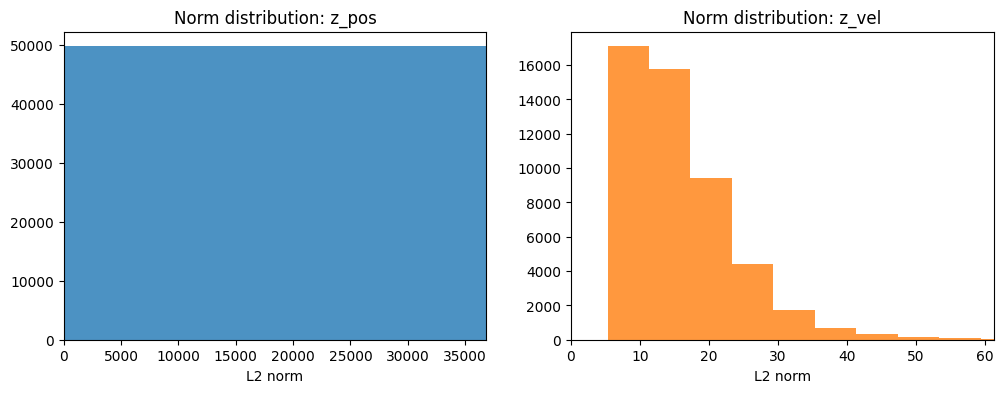

z_pos norm mean/std: 1398.46 37246.52
z_vel norm mean/std: 16.36 10.27


In [9]:
# Compare pos vs vel embedding norms.
pos_norm = np.linalg.norm(df_heavy[z_pos_cols].to_numpy(dtype=np.float32), axis=1)
vel_norm = np.linalg.norm(df_heavy[z_vel_cols].to_numpy(dtype=np.float32), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pos_norm, bins=60, alpha=0.8, color="tab:blue")
axes[0].set_title("Norm distribution: z_pos")
axes[1].hist(vel_norm, bins=60, alpha=0.8, color="tab:orange")
axes[1].set_title("Norm distribution: z_vel")
axes[0].set_xlabel("L2 norm")
axes[1].set_xlabel("L2 norm")
axes[0].set_xlim(0, np.percentile(pos_norm, 99.5))
axes[1].set_xlim(0, np.percentile(vel_norm, 99.5))
plt.show()

print("z_pos norm mean/std:", round(float(pos_norm.mean()), 2), round(float(pos_norm.std()), 2))
print("z_vel norm mean/std:", round(float(vel_norm.mean()), 2), round(float(vel_norm.std()), 2))


## Notes

- If `data/gazemae_outputs/` changes, update `EMBEDDINGS_PATH` and `SUMMARY_PATH` in the setup cell.
- For larger datasets, lower `MAX_ROWS_FOR_HEAVY` for faster exploratory runs.
